# 00. Lane View Validation + Single Image Probe

이 노트북은 Phase 3 Lane 실험의 첫 노트북임.

목적은 두 가지임.

1. `20260430_map_lab/_views` CSV가 실제 raw 파일을 제대로 가리키는지 확인함.
2. 대표 이미지 몇 장에서 `raw image -> crop/preprocess -> CLRKDNet FP32/PTQ -> decoder -> overlay` 흐름을 눈으로 확인함.

이 단계에서는 아직 batch 성능 결론을 내리지 않음. 먼저 모델 입력과 decoder 결과가 말이 되는지 이해하는 것이 목표임.

## 0. 사전 개념

02 문서에서 확인한 것처럼 CLRKDNet의 공식 출력은 `center_x`가 아니라 여러 lane curve 후보임.

따라서 이 노트북에서 확인할 것은 다음 순서임.

```text
raw image
-> crop_top 기준 crop
-> 800x320 BGR 0~1 tensor
-> CLRKDNet ONNX inference
-> lane 후보 192개 출력
-> 우리 decoder가 center_x 계산
-> overlay로 사람이 확인
```

여기서 `FP32`는 기준 모델이고, `PTQ`는 CULane 이미지로 calibration했던 기존 int8 모델임.

## 1. 환경 준비

필요 패키지:

```text
onnxruntime
opencv-python
matplotlib
pandas
numpy
```

패키지가 없으면 아래 주석을 해제해서 한 번만 실행하면 됨.

In [1]:
import sys
print(sys.executable)

~\anaconda3\envs\<env>\python.exe


In [2]:
# 필요 시 한 번만 실행
%pip install onnxruntime opencv-python matplotlib pandas numpy

  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached pyreadline3-3.5.4-py3-none-any.whl.metadata (4.7 kB)
   ---------------------------------------- 0.0/13.5 MB ? eta -:--:--
    --------------------------------------- 0.3/13.5 MB ? eta -:--:--
   - -------------------------------------- 0.5/13.5 MB 1.3 MB/s eta 0:00:11
   --- ------------------------------------ 1.0/13.5 MB 1.5 MB/s eta 0:00:09
   --- ------------------------------------ 1.3/13.5 MB 1.4 MB/s eta 0:00:09
   --- ------------------------------------ 1.3/13.5 MB 1.4 MB/s eta 0:00:09
   ----- ---------------------------------- 1.8/13.5 MB 1.4 MB/s eta 0:00:09
   ------ --------------------------------- 2.1/13.5 MB 1.4 MB/s eta 0:00:09
   ------- -------------------------------- 2.4/13.5 MB 1.4 MB/s eta 0:00:08
   -------- ------------------------------- 2.9/13.5 MB 1.4 MB/s eta 0:00:08
   ---------- ----------------------------- 3.4/13.5 MB 1.6 MB/s eta 0:00:07
   ------------ --------

In [3]:
from __future__ import annotations

from dataclasses import asdict
from pathlib import Path
import json
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization")
DATASET_ROOT = PROJECT_ROOT / "20260430_map_lab" / "20260430_map_lab"
VIEWS_ROOT = DATASET_ROOT / "_views"
MODEL_DIR = PROJECT_ROOT / "model"
FIELD_SCRIPT_DIR = PROJECT_ROOT / "field_experiment_scripts"
PHASE3_ROOT = PROJECT_ROOT / "phase3_lane_experiments"
OUTPUT_DIR = PHASE3_ROOT / "outputs" / "00_view_validation_and_single_probe"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "overlays").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "tables").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "summaries").mkdir(parents=True, exist_ok=True)

if str(FIELD_SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(FIELD_SCRIPT_DIR))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_ROOT:", DATASET_ROOT)
print("VIEWS_ROOT:", VIEWS_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization
DATASET_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20260430_map_lab\20260430_map_lab
VIEWS_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20260430_map_lab\20260430_map_lab\_views
OUTPUT_DIR: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\phase3_lane_experiments\outputs\00_view_validation_and_single_probe


In [4]:
from common_field import load_rgb, preprocess_rgb, draw_crop_line_rgb, save_rgb
from lane_model_utils import build_onnx_session, decode_lane_estimate, draw_lane_overlay_rgb

FP32_ONNX = MODEL_DIR / "clrkdnet_resnet18_culane.onnx"
PTQ_ONNX = MODEL_DIR / "clrkdnet_resnet18_culane_static_qoperator_int8.onnx"

assert FP32_ONNX.exists(), FP32_ONNX
assert PTQ_ONNX.exists(), PTQ_ONNX

print("FP32:", FP32_ONNX.name, FP32_ONNX.stat().st_size / 1024 / 1024, "MB")
print("PTQ :", PTQ_ONNX.name, PTQ_ONNX.stat().st_size / 1024 / 1024, "MB")

FP32: clrkdnet_resnet18_culane.onnx 43.959922790527344 MB
PTQ : clrkdnet_resnet18_culane_static_qoperator_int8.onnx 11.230716705322266 MB


## 2. `_views` CSV 검증

04 문서에서 원본 사진을 직접 이동하지 않고, 실험 목적별 CSV view를 만들었음.

여기서는 CSV row 수와 실제 파일 존재 여부를 먼저 확인함.

In [5]:
view_files = {
    "raw_lane": VIEWS_ROOT / "lane" / "raw_lane_images.csv",
    "map_driving_background": VIEWS_ROOT / "lane" / "map_driving_background_images.csv",
    "lane_ptq_calibration_candidates": VIEWS_ROOT / "lane" / "lane_ptq_calibration_candidates.csv",
}

views = {}
for name, path in view_files.items():
    assert path.exists(), path
    df = pd.read_csv(path)
    df["absolute_path"] = df["absolute_path"].astype(str)
    df["exists"] = df["absolute_path"].map(lambda p: Path(p).exists())
    views[name] = df
    print(f"{name}: rows={len(df)}, exists={df['exists'].sum()}, missing={(~df['exists']).sum()}")

assert all(df["exists"].all() for df in views.values()), "missing files exist in one or more views"

raw_lane: rows=1360, exists=1360, missing=0
map_driving_background: rows=500, exists=500, missing=0
lane_ptq_calibration_candidates: rows=1860, exists=1860, missing=0


In [6]:
raw_lane_counts = views["raw_lane"].groupby("label_or_scene").size().reset_index(name="count").sort_values("label_or_scene")
bg_counts = views["map_driving_background"].groupby("label_or_scene").size().reset_index(name="count")

display(raw_lane_counts)
display(bg_counts)

raw_lane_counts.to_csv(OUTPUT_DIR / "tables" / "raw_lane_counts.csv", index=False, encoding="utf-8-sig")
bg_counts.to_csv(OUTPUT_DIR / "tables" / "map_driving_background_counts.csv", index=False, encoding="utf-8-sig")

,label_or_scene,count
0,intersection,40
1,intersection_approach,60
2,intersection_left_entry,90
3,intersection_left_exit,30
4,intersection_right_entry,150
5,intersection_right_exit,30
6,left_curve,190
7,off_center_left,60
8,off_center_right,90
9,right_curve,400


,label_or_scene,count
0,background,500


## 3. 대표 이미지 샘플 확인

이 단계는 모델을 돌리기 전, raw 이미지와 crop 위치가 말이 되는지 확인하는 단계임.

기본 `crop_top=445`는 CULane의 `270/590` crop 비율을 Pi 카메라 높이 `972`에 맞춘 값임.

In [7]:
CROP_TOP = 445
CONF_THRESHOLD = 0.4
LOOKAHEAD_Y = 0.75

representative_scenes = [
    "straight",
    "left_curve",
    "right_curve",
    "intersection_approach",
    "intersection_left_entry",
    "intersection_right_entry",
    "off_center_left",
    "off_center_right",
]

def pick_first(df: pd.DataFrame, label: str) -> Path:
    rows = df[df["label_or_scene"] == label]
    if rows.empty:
        raise ValueError(f"no rows for label={label}")
    return Path(rows.iloc[0]["absolute_path"])

sample_paths = {scene: pick_first(views["raw_lane"], scene) for scene in representative_scenes}
sample_paths["map_driving_background"] = Path(views["map_driving_background"].iloc[0]["absolute_path"])

for label, path in sample_paths.items():
    print(label, "->", path.name)

straight -> 20260430_155237_lane_none_straight_none_center_0001.jpg
left_curve -> 20260430_155655_lane_none_left_curve_none_center_0001.jpg
right_curve -> 20260430_160025_lane_none_right_curve_none_center_0001.jpg
intersection_approach -> 20260430_163537_lane_none_intersection_approach_none_center_0001.jpg
intersection_left_entry -> 20260430_163608_lane_none_intersection_left_entry_none_center_0001.jpg
intersection_right_entry -> 20260430_163714_lane_none_intersection_right_entry_none_center_0001.jpg
off_center_left -> 20260430_164002_lane_none_off_center_left_none_left_0001.jpg
off_center_right -> 20260430_164103_lane_none_off_center_right_none_right_0001.jpg
map_driving_background -> 20260430_175024_signs_background_moving_mixed_right_0001.jpg


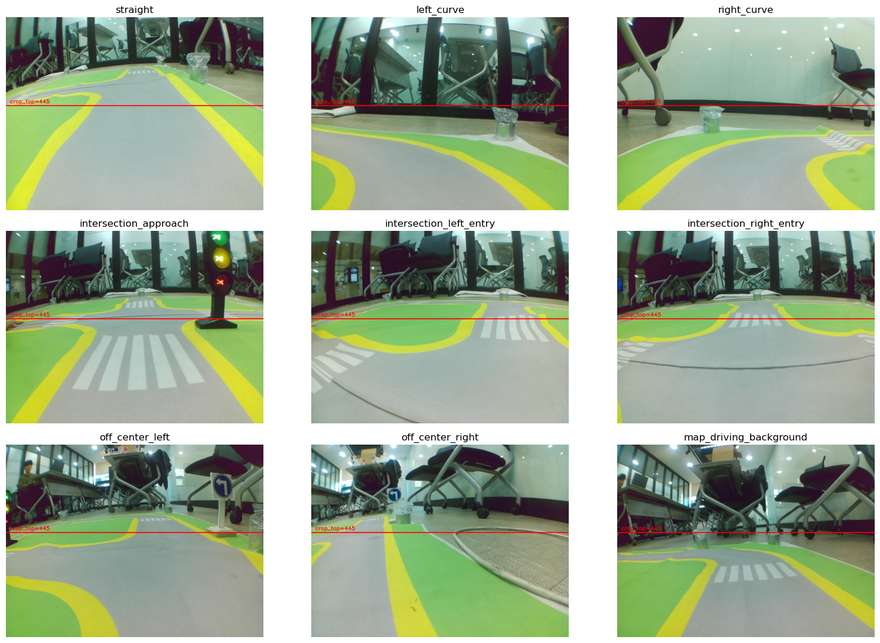

In [8]:
def show_grid(images, titles, cols=3, figsize=(15, 10)):
    rows = int(np.ceil(len(images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")
    for ax in axes[len(images):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

crop_line_images = []
titles = []
for label, path in sample_paths.items():
    raw = load_rgb(path)
    crop_line_images.append(draw_crop_line_rgb(raw, CROP_TOP))
    titles.append(label)

show_grid(crop_line_images, titles, cols=3, figsize=(16, 11))

## 4. 단일 이미지에서 전처리 확인

먼저 한 장을 골라 raw, crop line, 모델 입력 800x320을 비교함.

여기서 모델 입력 이미지에 노란선/도로가 이상하게 잘리면, 모델 결과를 보기 전에 crop부터 다시 봐야 함.

selected: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20260430_map_lab\20260430_map_lab\raw\lane\straight\20260430_155237_lane_none_straight_none_center_0001.jpg
raw shape: (972, 1296, 3)
tensor shape: (1, 3, 320, 800) dtype: float32 min/max: 0.12941177189350128 0.9647058844566345


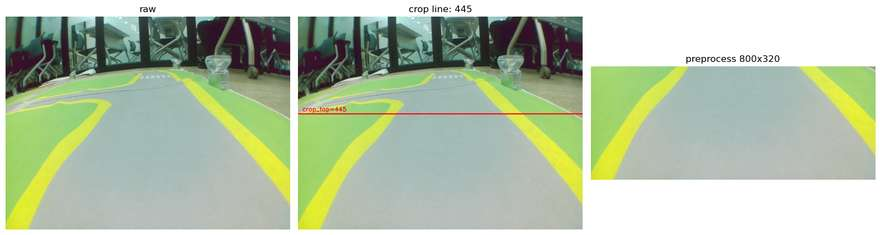

In [9]:
SELECTED_LABEL = "straight"  # 필요하면 여기만 바꿔서 한 장씩 확인
selected_path = sample_paths[SELECTED_LABEL]

raw_rgb = load_rgb(selected_path)
tensor, preprocess_rgb_image = preprocess_rgb(raw_rgb, crop_top=CROP_TOP)
crop_line_rgb = draw_crop_line_rgb(raw_rgb, CROP_TOP)

print("selected:", selected_path)
print("raw shape:", raw_rgb.shape)
print("tensor shape:", tensor.shape, "dtype:", tensor.dtype, "min/max:", float(tensor.min()), float(tensor.max()))

show_grid([raw_rgb, crop_line_rgb, preprocess_rgb_image], ["raw", f"crop line: {CROP_TOP}", "preprocess 800x320"], cols=3, figsize=(16, 5))

## 5. FP32 / PTQ 모델 로드

이 단계부터 ONNX Runtime을 사용함.

thread 수는 일단 4로 둠. 이 노트북의 목적은 latency 측정이 아니라 output sanity 확인임.

In [10]:
THREADS = 4

fp32_session = build_onnx_session(FP32_ONNX, threads=THREADS)
ptq_session = build_onnx_session(PTQ_ONNX, threads=THREADS)

def describe_session(name, session):
    inputs = session.get_inputs()
    outputs = session.get_outputs()
    print(f"[{name}]")
    for x in inputs:
        print(" input ", x.name, x.shape, x.type)
    for y in outputs:
        print(" output", y.name, y.shape, y.type)

describe_session("FP32", fp32_session)
describe_session("PTQ", ptq_session)

[FP32]
 input  image ['batch', 3, 320, 800] tensor(float)
 output raw_predictions ['batch', 'ScatterNDraw_predictions_dim_1', 'ScatterNDraw_predictions_dim_2'] tensor(float)
[PTQ]
 input  image ['batch', 3, 320, 800] tensor(float)
 output raw_predictions ['batch', 'ScatterNDraw_predictions_dim_1', 'ScatterNDraw_predictions_dim_2'] tensor(float)


## 6. 단일 이미지 inference + overlay

`decode_lane_estimate()`는 공식 CLRKDNet postprocess가 아니라, 우리 자동차 제어용 `center_x`를 얻기 위한 rough decoder임.

여기서는 다음을 확인함.

- FP32와 PTQ가 같은 이미지에서 비슷한 reason을 내는가?
- center_x 초록선이 도로 중앙 근처에 있는가?
- `both_lanes`, `left_only`, `right_only`, `no_lane` reason이 눈으로 봐도 납득되는가?

FP32 output shape: (1, 192, 78)
PTQ output shape : (1, 192, 78)
FP32 estimate: {'center_x': None, 'offset': 0.0, 'confidence': 0.0, 'left_x': None, 'right_x': None, 'lane_count': 0, 'reason': 'no_lane'}
PTQ estimate : {'center_x': None, 'offset': 0.0, 'confidence': 0.0, 'left_x': None, 'right_x': None, 'lane_count': 0, 'reason': 'no_lane'}


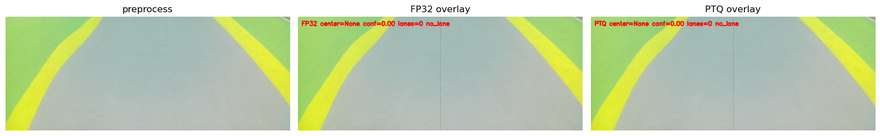

In [11]:
def run_decoder(session, tensor, label: str):
    input_name = session.get_inputs()[0].name
    output = session.run(None, {input_name: tensor})[0]
    estimate, lane_width, lane_samples = decode_lane_estimate(
        output,
        conf_threshold=CONF_THRESHOLD,
        lookahead_y=LOOKAHEAD_Y,
    )
    overlay = draw_lane_overlay_rgb(preprocess_rgb_image, estimate, lane_samples, title=label)
    return output, estimate, lane_width, lane_samples, overlay

fp32_output, fp32_est, fp32_lane_width, fp32_samples, fp32_overlay = run_decoder(fp32_session, tensor, "FP32")
ptq_output, ptq_est, ptq_lane_width, ptq_samples, ptq_overlay = run_decoder(ptq_session, tensor, "PTQ")

print("FP32 output shape:", fp32_output.shape)
print("PTQ output shape :", ptq_output.shape)
print("FP32 estimate:", asdict(fp32_est))
print("PTQ estimate :", asdict(ptq_est))

show_grid([preprocess_rgb_image, fp32_overlay, ptq_overlay], ["preprocess", "FP32 overlay", "PTQ overlay"], cols=3, figsize=(16, 5))

In [12]:
save_rgb(OUTPUT_DIR / "overlays" / f"{SELECTED_LABEL}_preprocess.jpg", preprocess_rgb_image)
save_rgb(OUTPUT_DIR / "overlays" / f"{SELECTED_LABEL}_fp32_overlay.jpg", fp32_overlay)
save_rgb(OUTPUT_DIR / "overlays" / f"{SELECTED_LABEL}_ptq_overlay.jpg", ptq_overlay)

single_result = {
    "selected_label": SELECTED_LABEL,
    "selected_path": str(selected_path),
    "crop_top": CROP_TOP,
    "conf_threshold": CONF_THRESHOLD,
    "lookahead_y": LOOKAHEAD_Y,
    "fp32_estimate": asdict(fp32_est),
    "ptq_estimate": asdict(ptq_est),
}

(OUTPUT_DIR / "summaries" / f"{SELECTED_LABEL}_single_probe.json").write_text(
    json.dumps(single_result, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("saved to", OUTPUT_DIR)

saved to ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\phase3_lane_experiments\outputs\00_view_validation_and_single_probe


## 7. 대표 scene 1장씩 빠른 probe

아직 batch baseline은 아님. scene별로 한 장씩만 빠르게 돌려서, 어떤 scene부터 문제가 보이는지 감을 잡는 단계임.

여기서 이미 crop이나 decoder가 말이 안 되면, 전체 batch로 넘어가기 전에 먼저 고쳐야 함.

In [13]:
def probe_one(label: str, path: Path):
    raw = load_rgb(path)
    tensor_i, prep = preprocess_rgb(raw, crop_top=CROP_TOP)

    results = []
    overlays = []
    titles = []
    for model_name, session in [("fp32", fp32_session), ("ptq", ptq_session)]:
        input_name = session.get_inputs()[0].name
        output = session.run(None, {input_name: tensor_i})[0]
        est, lane_width, samples = decode_lane_estimate(output, CONF_THRESHOLD, LOOKAHEAD_Y)
        overlay = draw_lane_overlay_rgb(prep, est, samples, title=f"{model_name}:{label}")
        overlays.append(overlay)
        titles.append(f"{label} / {model_name} / {est.reason}")
        results.append({
            "label_or_scene": label,
            "model": model_name,
            "file_name": path.name,
            "path": str(path),
            "center_x": est.center_x,
            "offset": est.offset,
            "confidence": est.confidence,
            "left_x": est.left_x,
            "right_x": est.right_x,
            "lane_count": est.lane_count,
            "reason": est.reason,
        })
        out_path = OUTPUT_DIR / "overlays" / f"quick_{label}_{model_name}.jpg"
        save_rgb(out_path, overlay)
    return results, overlays, titles

quick_rows = []
quick_overlays = []
quick_titles = []
for label, path in sample_paths.items():
    rows, overlays, titles = probe_one(label, path)
    quick_rows.extend(rows)
    quick_overlays.extend(overlays)
    quick_titles.extend(titles)

quick_df = pd.DataFrame(quick_rows)
display(quick_df)
quick_df.to_csv(OUTPUT_DIR / "tables" / "quick_scene_probe.csv", index=False, encoding="utf-8-sig")

,label_or_scene,model,file_name,path,center_x,offset,confidence,left_x,right_x,lane_count,reason
0,straight,fp32,20260430_155237_lane_none_straight_none_center...,~\02_Projects\University\26-1_Em...,None,0.0,0.0,None,None,0,no_lane
1,straight,ptq,20260430_155237_lane_none_straight_none_center...,~\02_Projects\University\26-1_Em...,None,0.0,0.0,None,None,0,no_lane
2,left_curve,fp32,20260430_155655_lane_none_left_curve_none_cent...,~\02_Projects\University\26-1_Em...,None,0.0,0.0,None,None,0,no_lane
3,left_curve,ptq,20260430_155655_lane_none_left_curve_none_cent...,~\02_Projects\University\26-1_Em...,None,0.0,0.0,None,None,0,no_lane
4,right_curve,fp32,20260430_160025_lane_none_right_curve_none_cen...,~\02_Projects\University\26-1_Em...,None,0.0,0.0,None,None,0,no_lane
5,right_curve,ptq,20260430_160025_lane_none_right_curve_none_cen...,~\02_Projects\University\26-1_Em...,None,0.0,0.0,None,None,0,no_lane
6,intersection_approach,fp32,20260430_163537_lane_none_intersection_approac...,~\02_Projects\University\26-1_Em...,None,0.0,0.0,None,None,0,no_lane
7,intersection_approach,ptq,20260430_163537_lane_none_intersection_approac...,~\02_Projects\University\26-1_Em...,None,0.0,0.0,None,None,0,no_lane
8,intersection_left_entry,fp32,20260430_163608_lane_none_intersection_left_en...,~\02_Projects\University\26-1_Em...,None,0.0,0.0,None,None,0,no_lane
9,intersection_left_entry,ptq,20260430_163608_lane_none_intersection_left_en...,~\02_Projects\University\26-1_Em...,None,0.0,0.0,None,None,0,no_lane


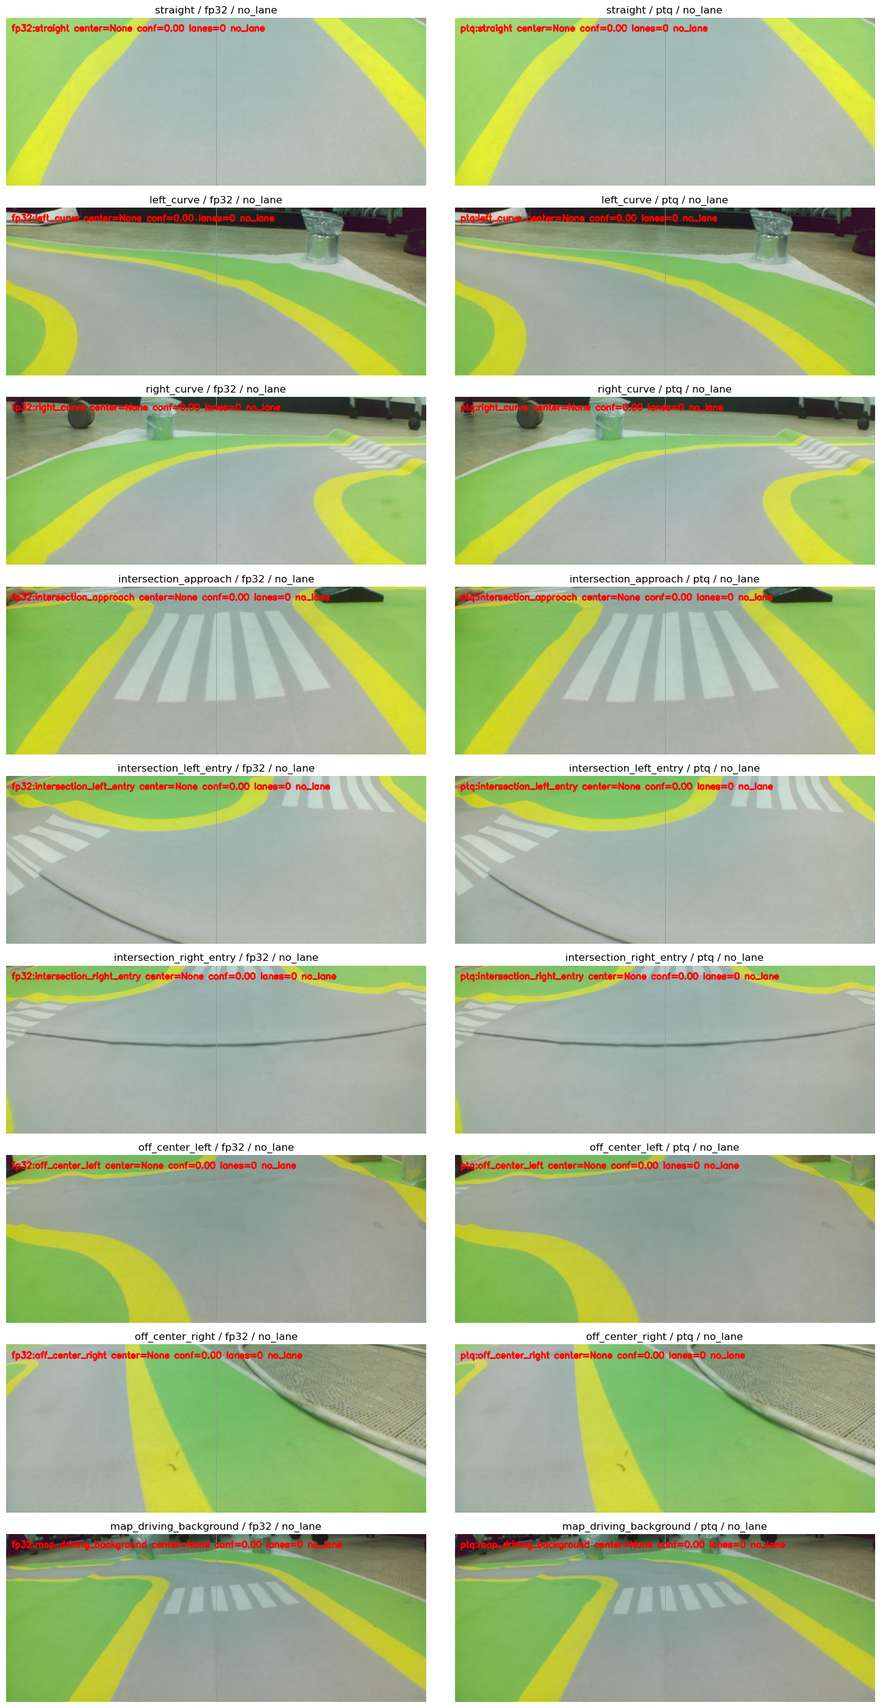

In [14]:
show_grid(quick_overlays, quick_titles, cols=2, figsize=(15, 28))

## 8. Confidence threshold 진단

위 결과가 전부 `no_lane`으로 나오면, 정말 모델 출력이 없는 것인지 아니면 `conf_threshold=0.4`가 우리 map 이미지에 너무 높은 것인지 구분해야 함.

여기서는 대표 scene 1장씩에 대해 raw lane score의 최대값과 threshold별 decoder 결과를 확인함.

주의: threshold를 낮추면 lane 후보가 늘지만, 가짜 후보도 같이 늘 수 있음. 따라서 이 표는 최종 설정이 아니라 원인 진단용임.

In [15]:
from lane_model_utils import softmax2

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40]
diag_rows = []

for label, path in sample_paths.items():
    raw = load_rgb(path)
    tensor_i, _ = preprocess_rgb(raw, crop_top=CROP_TOP)

    for model_name, session in [("fp32", fp32_session), ("ptq", ptq_session)]:
        input_name = session.get_inputs()[0].name
        output = session.run(None, {input_name: tensor_i})[0]
        scores = softmax2(output[0, :, :2])[:, 1]

        row = {
            "label_or_scene": label,
            "model": model_name,
            "file_name": path.name,
            "max_score": float(scores.max()),
            "mean_score": float(scores.mean()),
        }

        for th in thresholds:
            est, _, _ = decode_lane_estimate(output, conf_threshold=th, lookahead_y=LOOKAHEAD_Y)
            key = f"th_{th:.2f}"
            row[f"{key}_keep"] = int((scores >= th).sum())
            row[f"{key}_reason"] = est.reason
            row[f"{key}_center_x"] = est.center_x
            row[f"{key}_confidence"] = est.confidence

        diag_rows.append(row)

threshold_diag_df = pd.DataFrame(diag_rows)
display_cols = [
    "label_or_scene",
    "model",
    "max_score",
    "th_0.20_reason",
    "th_0.20_center_x",
    "th_0.25_reason",
    "th_0.25_center_x",
    "th_0.40_reason",
]
display(threshold_diag_df[display_cols])

threshold_diag_df.to_csv(OUTPUT_DIR / "tables" / "quick_threshold_diagnosis.csv", index=False, encoding="utf-8-sig")


,label_or_scene,model,max_score,th_0.20_reason,th_0.20_center_x,th_0.25_reason,th_0.25_center_x,th_0.40_reason
0,straight,fp32,0.246978,both_lanes,0.528402,no_lane,NaN,no_lane
1,straight,ptq,0.240710,both_lanes,0.522901,no_lane,NaN,no_lane
2,left_curve,fp32,0.101438,no_lane,NaN,no_lane,NaN,no_lane
3,left_curve,ptq,0.112263,no_lane,NaN,no_lane,NaN,no_lane
4,right_curve,fp32,0.111322,no_lane,NaN,no_lane,NaN,no_lane
5,right_curve,ptq,0.137280,no_lane,NaN,no_lane,NaN,no_lane
6,intersection_approach,fp32,0.082271,no_lane,NaN,no_lane,NaN,no_lane
7,intersection_approach,ptq,0.091323,no_lane,NaN,no_lane,NaN,no_lane
8,intersection_left_entry,fp32,0.113703,no_lane,NaN,no_lane,NaN,no_lane
9,intersection_left_entry,ptq,0.112263,no_lane,NaN,no_lane,NaN,no_lane


## 9. 검증 메모

아래는 실행 후 직접 채우는 메모임.

### 9.1 view 검증

- [ ] `_views/lane/raw_lane_images.csv` 파일들이 모두 존재함.
- [ ] `_views/lane/map_driving_background_images.csv` 파일들이 모두 존재함.
- [ ] scene 분포가 04 문서와 일치함.

### 9.2 crop 확인

- crop_top=445에서 차선이 충분히 남는가:
- 코너/교차로에서 너무 많이 잘리는가:
- background 주행 프레임에서도 도로/노란선이 남는가:

### 9.3 FP32/PTQ 단일 이미지 확인

- FP32 reason:
- PTQ reason:
- FP32와 PTQ의 center_x 차이:
- overlay 초록선이 실제 도로 중앙에 가까운가:

### 9.4 다음 판단

- [ ] batch baseline으로 넘어가도 됨.
- [ ] crop_top부터 다시 봐야 함.
- [ ] decoder가 이상해서 먼저 수정해야 함.
- [ ] PTQ가 FP32 대비 너무 달라서 Map PTQ 후보를 빨리 봐야 함.